In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# Transcriptomics

In [3]:
liver_t = pd.read_csv('Transcriptomics/RNA_liver_output_05122025.csv', index_col=0)
print(liver_t.Gene.duplicated().sum())
print(liver_t.shape)
hcc_t = pd.read_csv('Transcriptomics/RNA_hcc_output_04122025.csv', index_col=0)
print(hcc_t.Gene.duplicated().sum())
print(hcc_t.shape)


liver_t = liver_t.loc[:,['log2FoldChange', 'padj', 'Gene']]
hcc_t = hcc_t.loc[:,['log2FoldChange', 'padj', 'Gene']]

liver_t.columns = ['log2FC_liver_rna', 'padj_liver_rna', 'Gene']
hcc_t.columns = ['log2FC_hcc_rna', 'padj_hcc_rna', 'Gene']

liver_t = liver_t.groupby('Gene').mean()
hcc_t = hcc_t.groupby('Gene').mean()

df_rna = pd.concat([liver_t, hcc_t], axis=1)
df_rna.head()

1
(15723, 41)
2
(16575, 41)


,log2FC_liver_rna,padj_liver_rna,log2FC_hcc_rna,padj_hcc_rna
Gene,,,,
A1BG,-0.407155,0.050839,-0.312457,0.511969
A1CF,0.222169,0.002739,0.224063,0.195116
A2M,-0.036842,0.785789,0.140596,0.675049
A2ML1,0.316283,0.668752,0.734193,0.539805
A4GALT,-0.152066,0.609186,-0.892406,0.013012


# Proteomics

In [78]:
prot_liver = pd.read_csv('proteomics/prot_ttest_liver_2025-12-11.csv', index_col=0)
prot_liver = prot_liver.loc[:,['Gene', 'ResectionvsBiopsy_pval', 'ResectionvsBiopsy_fc',
       'ResectionvsBiopsy_adj_pval']]
prot_liver.columns = prot_liver.columns + '_liver'

prot_hcc = pd.read_csv('proteomics/prot_ttest_hcc_2025-12-11.csv', index_col=0)
prot_hcc = prot_hcc.loc[:,['Gene', 'ResectionvsBiopsy_pval', 'ResectionvsBiopsy_fc',
       'ResectionvsBiopsy_adj_pval']]
prot_hcc.columns = prot_hcc.columns + '_hcc'

prot = pd.concat([prot_liver, prot_hcc], axis=1).reset_index()

drop = []
for col in prot.columns:
    if col.startswith('missingindicator'):
        drop.append(col)
prot = prot.drop(drop, axis=1)

prot = prot.rename({'ResectionvsBiopsy_fc_liver':'log2FC_liver_prot',
                    'ResectionvsBiopsy_fc_hcc':'log2FC_hcc_prot'}, axis=1)

prot['Gene'] = np.where(prot.Gene_hcc.isna(), prot.Gene_liver, prot.Gene_hcc)
prot = prot.drop(['Gene_liver', 'Gene_hcc'], axis=1)

prot.index = prot.Gene

prot.shape

(6875, 8)

In [79]:
prot.head()

,ID,ResectionvsBiopsy_pval_liver,log2FC_liver_prot,ResectionvsBiopsy_adj_pval_liver,ResectionvsBiopsy_pval_hcc,log2FC_hcc_prot,ResectionvsBiopsy_adj_pval_hcc,Gene
Gene,,,,,,,,
SERPINA10,SERPINA10,1.242505e-10,3.952586,7.673712e-07,0.005250,-0.839100,0.106875,SERPINA10
ATF2,ATF2,4.076864e-10,4.365055,1.258936e-06,0.011327,-0.936136,0.147867,ATF2
RBMX2,RBMX2,9.130857e-10,-4.471596,1.700209e-06,0.898184,0.038017,0.958129,RBMX2
SGF29,SGF29,1.322015e-09,-4.295217,1.700209e-06,0.238494,-0.216711,0.529926,SGF29
ZNF384,ZNF384,1.376464e-09,-4.470819,1.700209e-06,0.151408,-0.544238,0.443024,ZNF384


# Phospho

In [80]:
liver_phospho = pd.read_csv('phospho_proteomics/phospho_ttest_Liver_2025-12-11.csv', index_col=0)
liver_phospho = liver_phospho.rename({'Gene': 'Gene_site'}, axis=1)
liver_phospho['Gene_name'] = liver_phospho.Gene_site.str.split('_').str[0]
print(liver_phospho.Gene_name.duplicated().sum())
print(liver_phospho.shape)
print(liver_phospho.Gene_site.duplicated().sum())

liver_phospho = liver_phospho.loc[:,['ResectionvsBiopsy_adj_pval', 'ResectionvsBiopsy_fc',
                                     'Gene_site', 'Gene_name']]
liver_phospho.columns = ['padj_liver_phos', 'log2FC_liver_phos', 'Gene_site', 'Gene_name']

liver_phospho = liver_phospho.groupby(['Gene_site', 'Gene_name']).mean()
print(liver_phospho.head())

hcc_phospho = pd.read_csv('phospho_proteomics/phospho_ttest_hcc_2025-12-11.csv', index_col=0)
hcc_phospho = hcc_phospho.rename({'Gene': 'Gene_site'}, axis=1)
hcc_phospho['Gene_name'] = hcc_phospho.Gene_site.str.split('_').str[0]

hcc_phospho = hcc_phospho.loc[:,['ResectionvsBiopsy_adj_pval', 'ResectionvsBiopsy_fc',
                                     'Gene_site', 'Gene_name']]

hcc_phospho.columns = ['padj_hcc_phos', 'log2FC_hcc_phos', 'Gene_site', 'Gene_name']

hcc_phospho = hcc_phospho.groupby(['Gene_site', 'Gene_name']).mean()

df_phos = pd.concat([liver_phospho, hcc_phospho], axis=1).reset_index()

3245
(5780, 44)
0
                     padj_liver_phos  log2FC_liver_phos
Gene_site Gene_name                                    
AAAS_S495 AAAS              0.906266           0.248104
AAK1_S623 AAK1              0.721160          -0.459443
AAK1_S624 AAK1              0.213425           1.285905
AAK1_S637 AAK1              0.719029          -0.571556
AAK1_T389 AAK1              0.142795           1.458441


In [81]:
df_phos.head()

,Gene_site,Gene_name,padj_liver_phos,log2FC_liver_phos,padj_hcc_phos,log2FC_hcc_phos
0,AAAS_S495,AAAS,0.906266,0.248104,0.650823,0.333031
1,AAK1_S623,AAK1,0.721160,-0.459443,NaN,NaN
2,AAK1_S624,AAK1,0.213425,1.285905,0.042836,1.339144
3,AAK1_S637,AAK1,0.719029,-0.571556,0.299841,0.670702
4,AAK1_T389,AAK1,0.142795,1.458441,0.748502,0.182984


In [82]:
df_phos = df_phos.drop('Gene_site', axis=1)

In [83]:
df_phos.Gene_name = df_phos.Gene_name.str.replace(';', '')
df_phos = df_phos.dropna(subset='Gene_name')
df_phos.padj_liver_phos = df_phos.padj_liver_phos.fillna(1)
df_phos.padj_hcc_phos = df_phos.padj_hcc_phos.fillna(1)
#df_phos = df_phos.drop('Gene_site', axis=1)
df_phos_g = df_phos.groupby('Gene_name').mean()

# For each gene, find the index (row) of the site with the lowest p-value
idx_l = df_phos.groupby('Gene_name')['padj_liver_phos'].idxmin()

idx_h = df_phos.groupby('Gene_name')['padj_hcc_phos'].idxmin()

# Select those rows from the original dataframe
df_phos_l = df_phos.loc[idx_l].reset_index(drop=True)
df_phos_l.index = df_phos_l.Gene_name
df_phos_h = df_phos.loc[idx_h].reset_index(drop=True)
df_phos_h.index = df_phos_h.Gene_name
df_phos_g = pd.concat([df_phos_l.loc[:,['log2FC_hcc_phos', 'padj_hcc_phos']],
                       df_phos_h.loc[:,['log2FC_liver_phos', 'padj_liver_phos']]], axis=1)

#df_phos_g.index = df_phos_g.Gene_name

In [84]:
df_phos_g.head()

,log2FC_hcc_phos,padj_hcc_phos,log2FC_liver_phos,padj_liver_phos
Gene_name,,,,
AAAS,0.333031,0.650823,0.248104,0.906266
AAK1,1.678567,0.019372,0.981511,0.094832
AATF,NaN,1.000000,-0.814355,0.245290
ABCB11,1.580775,0.007738,NaN,1.000000
ABCC1,NaN,1.000000,0.143850,0.935707


# Join RNA and Proteome and Phospho

In [85]:
df_rna.index.duplicated().sum()

0

In [86]:
prot.index.duplicated().sum()

0

In [87]:
df_cat = pd.concat([df_rna, prot, df_phos_g], axis=1)
#df_cat = df_cat.dropna()
df_cat.head()

,log2FC_liver_rna,padj_liver_rna,log2FC_hcc_rna,padj_hcc_rna,ID,ResectionvsBiopsy_pval_liver,log2FC_liver_prot,ResectionvsBiopsy_adj_pval_liver,ResectionvsBiopsy_pval_hcc,log2FC_hcc_prot,ResectionvsBiopsy_adj_pval_hcc,Gene,log2FC_hcc_phos,padj_hcc_phos,log2FC_liver_phos,padj_liver_phos
A1BG,-0.407155,0.050839,-0.312457,0.511969,A1BG,0.102491,-0.367399,0.289450,0.002814,-0.802364,0.083766,A1BG,NaN,NaN,NaN,NaN
A1CF,0.222169,0.002739,0.224063,0.195116,A1CF,0.438713,0.085817,0.646773,0.554212,0.064566,0.775825,A1CF,NaN,NaN,NaN,NaN
A2M,-0.036842,0.785789,0.140596,0.675049,A2M,0.017507,-1.060121,0.117969,0.005115,-1.498272,0.105722,A2M,NaN,NaN,NaN,NaN
A2ML1,0.316283,0.668752,0.734193,0.539805,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A4GALT,-0.152066,0.609186,-0.892406,0.013012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [88]:
df_cat.isna().sum()

log2FC_liver_rna                     1211
padj_liver_rna                       1211
log2FC_hcc_rna                        360
padj_hcc_rna                          360
ID                                  10058
ResectionvsBiopsy_pval_liver        10757
log2FC_liver_prot                   10757
ResectionvsBiopsy_adj_pval_liver    10757
ResectionvsBiopsy_pval_hcc          10236
log2FC_hcc_prot                     10236
ResectionvsBiopsy_adj_pval_hcc      10236
Gene                                10058
log2FC_hcc_phos                     14931
padj_hcc_phos                       14289
log2FC_liver_phos                   14499
padj_liver_phos                     14289
dtype: int64

In [89]:
df_cat.shape

(16933, 16)

<Axes: xlabel='log2FC_liver_rna', ylabel='log2FC_liver_prot'>

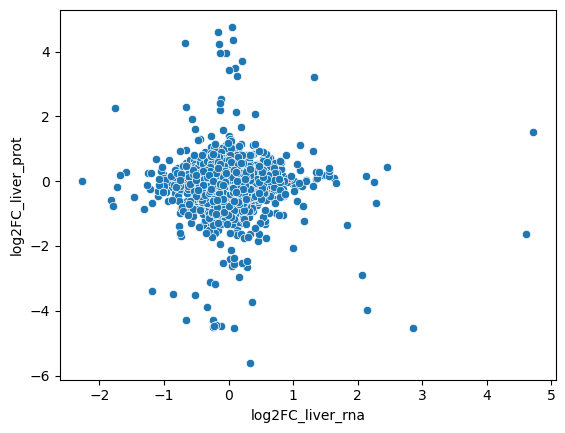

In [90]:
sns.scatterplot(data=df_cat, x='log2FC_liver_rna', y='log2FC_liver_prot')

<Axes: xlabel='log2FC_liver_rna', ylabel='log2FC_liver_phos'>

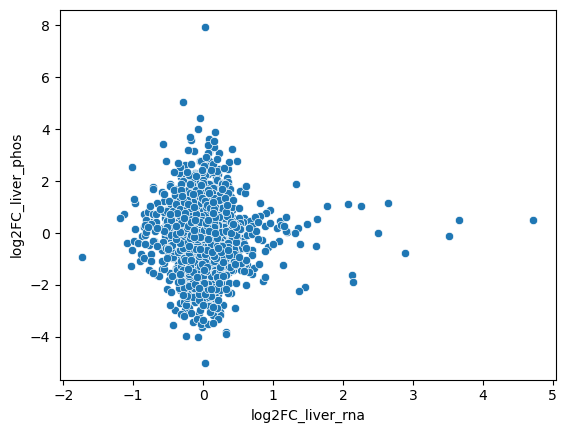

In [91]:
sns.scatterplot(data=df_cat, x='log2FC_liver_rna', y='log2FC_liver_phos')

<Axes: xlabel='log2FC_liver_prot', ylabel='log2FC_liver_phos'>

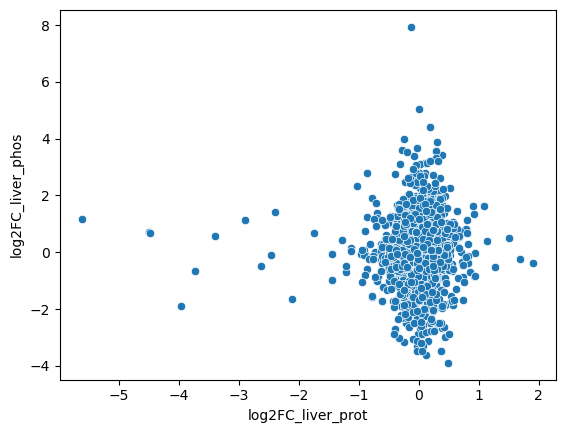

In [92]:
sns.scatterplot(data=df_cat, x='log2FC_liver_prot', y='log2FC_liver_phos')

<Axes: xlabel='log2FC_hcc_phos', ylabel='log2FC_liver_phos'>

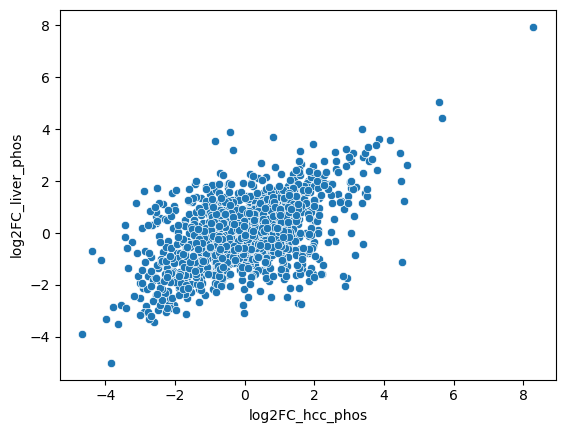

In [93]:
sns.scatterplot(data=df_cat, x='log2FC_hcc_phos', y='log2FC_liver_phos')

In [94]:
df_cat[df_cat.log2FC_hcc_phos > 1]

,log2FC_liver_rna,padj_liver_rna,log2FC_hcc_rna,padj_hcc_rna,ID,ResectionvsBiopsy_pval_liver,log2FC_liver_prot,ResectionvsBiopsy_adj_pval_liver,ResectionvsBiopsy_pval_hcc,log2FC_hcc_prot,ResectionvsBiopsy_adj_pval_hcc,Gene,log2FC_hcc_phos,padj_hcc_phos,log2FC_liver_phos,padj_liver_phos
AAK1,0.255877,0.081410,0.278646,0.236001,AAK1,0.118224,0.243105,0.313504,0.627258,0.089266,0.815363,AAK1,1.678567,0.019372,0.981511,0.094832
ABCB11,0.110703,0.494695,0.081125,0.857583,ABCB11,0.500380,-0.105118,0.692903,0.782334,-0.066908,0.899449,ABCB11,1.580775,0.007738,NaN,1.000000
ABLIM1,0.357203,0.011370,0.225241,0.236001,ABLIM1,0.184453,0.088863,0.391606,0.955813,-0.012604,0.980031,ABLIM1,1.532210,0.062350,0.356156,0.491157
ACACB,-0.237007,0.110681,-0.146468,0.460343,ACACB,0.787782,-0.047209,0.885130,0.188482,0.330698,0.481965,ACACB,4.496044,0.007069,1.994265,0.144612
ADGRE5,0.307056,0.008661,-0.394094,0.134924,ADGRE5,0.338500,-0.382956,0.562891,0.031269,-0.846357,0.235559,ADGRE5,1.424215,0.032644,0.036803,0.967918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ARL6IP4,NaN,NaN,-0.038563,0.958507,ARL6IP4,0.421023,0.123056,0.631323,0.061548,0.296549,0.296291,ARL6IP4,1.264975,0.046836,1.448974,0.225015
FBP2,NaN,NaN,0.691755,0.545682,FBP2,0.915713,-0.025320,0.958712,0.110104,-0.349920,0.388532,FBP2,1.844664,0.004124,-0.039605,0.986742
CAST,NaN,NaN,NaN,NaN,CAST,0.070356,0.236105,0.236012,0.453041,-0.154856,0.709214,CAST,2.871383,0.004859,-2.038947,0.030350
PRP4K,NaN,NaN,NaN,NaN,PRP4K,0.835398,-0.037140,0.914790,0.128509,0.261507,0.412573,PRP4K,1.001479,0.191085,0.710292,0.356434


<Axes: xlabel='log2FC_hcc_rna', ylabel='log2FC_hcc_prot'>

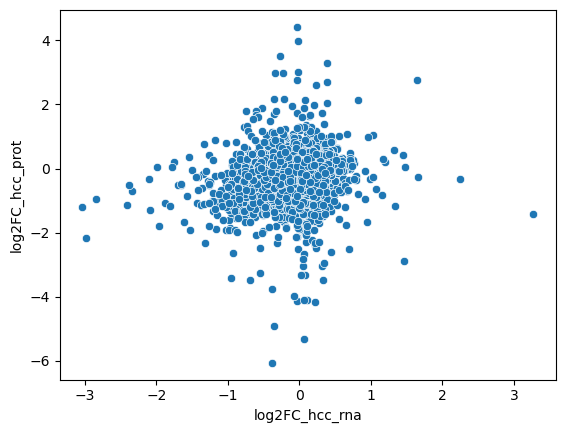

In [95]:
sns.scatterplot(data=df_cat, x='log2FC_hcc_rna', y='log2FC_hcc_prot')

<Axes: xlabel='log2FC_liver_rna', ylabel='log2FC_hcc_rna'>

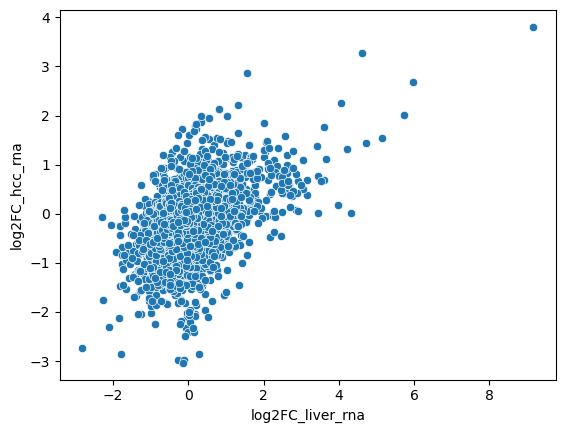

In [96]:
sns.scatterplot(data=df_cat, x='log2FC_liver_rna', y='log2FC_hcc_rna')

<Axes: xlabel='log2FC_liver_prot', ylabel='log2FC_hcc_prot'>

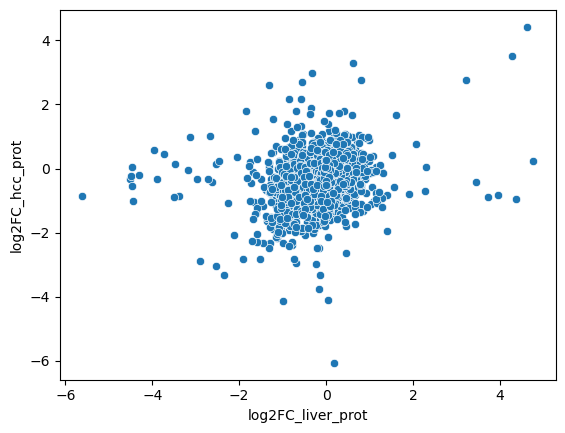

In [97]:
sns.scatterplot(data=df_cat, x='log2FC_liver_prot', y='log2FC_hcc_prot')

In [98]:
df_cat_sig = df_cat[
    (df_cat[[col for col in df_cat.columns if col.startswith('padj')]] < 0.05).any(axis=1)
].copy()

df_cat_sig = df_cat_sig[
    (df_cat_sig[[col for col in df_cat_sig.columns if col.startswith('log2')]].abs() > 1).any(axis=1)
]

df_cat_sig.shape

(1633, 16)

In [99]:
hypoxia_genes = pd.read_excel('nar-00809-h-2009-File011.xls', skiprows=1)
hypoxia_genes = hypoxia_genes.Symbol
hypoxia_genes

0      ABCB1
1      ABCG2
2        ADM
3     ADRA1B
4        AK3
       ...  
82     TGFB3
83      TGM2
84      TPI1
85     VEGFA
86       VIM
Name: Symbol, Length: 87, dtype: object

In [100]:
df_cat_hypoxia = df_cat[df_cat.index.isin(hypoxia_genes.tolist())].copy()

In [101]:
df_cat_hypoxia.columns

Index(['log2FC_liver_rna', 'padj_liver_rna', 'log2FC_hcc_rna', 'padj_hcc_rna',
       'ID', 'ResectionvsBiopsy_pval_liver', 'log2FC_liver_prot',
       'ResectionvsBiopsy_adj_pval_liver', 'ResectionvsBiopsy_pval_hcc',
       'log2FC_hcc_prot', 'ResectionvsBiopsy_adj_pval_hcc', 'Gene',
       'log2FC_hcc_phos', 'padj_hcc_phos', 'log2FC_liver_phos',
       'padj_liver_phos'],
      dtype='object')

In [106]:
df_cat_hypoxia['padj_hcc_prot'] = df_cat_hypoxia['ResectionvsBiopsy_adj_pval_hcc']
df_cat_hypoxia['padj_liver_prot'] = df_cat_hypoxia['ResectionvsBiopsy_adj_pval_liver']
df_cat_hypoxia = df_cat_hypoxia.drop(['ResectionvsBiopsy_adj_pval_liver', 'ResectionvsBiopsy_adj_pval_hcc'], axis=1)
df_cat_hypoxia

,log2FC_liver_rna,padj_liver_rna,log2FC_hcc_rna,padj_hcc_rna,ID,ResectionvsBiopsy_pval_liver,log2FC_liver_prot,ResectionvsBiopsy_pval_hcc,log2FC_hcc_prot,Gene,log2FC_hcc_phos,padj_hcc_phos,log2FC_liver_phos,padj_liver_phos,padj_hcc_prot,padj_liver_prot
ABCB1,-0.243443,8.261282e-02,0.038150,0.935591,ABCB1,0.345763,-0.165554,0.857013,-0.043304,ABCB1,NaN,NaN,NaN,NaN,0.935965,0.569028
ABCG2,0.099038,5.699418e-01,-0.081601,0.881601,ABCG2,NaN,NaN,0.873869,-0.073355,ABCG2,NaN,NaN,NaN,NaN,0.946361,NaN
ADM,1.590893,1.186028e-10,0.146294,0.781950,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ADRA1B,-0.264100,5.944544e-02,-0.529419,0.152352,NaN,NaN,NaN,NaN,NaN,NaN,-2.380366,0.003496,NaN,1.000000,NaN,NaN
AK3,0.117181,2.728757e-01,0.219503,0.246061,AK3,0.554158,0.082642,0.157970,-0.175386,AK3,NaN,NaN,NaN,NaN,0.450921,0.734911
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VIM,0.291639,3.634558e-02,-0.301478,0.317383,VIM,0.756197,0.067818,0.139982,-0.594767,VIM,NaN,1.000000,2.490386,0.192189,0.429437,0.868565
LEP,NaN,NaN,0.281093,0.838805,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PROK1,NaN,NaN,-0.214661,0.938350,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TERT,NaN,NaN,0.032580,0.956461,TERT,NaN,NaN,0.000778,1.618738,TERT,NaN,NaN,NaN,NaN,0.044912,NaN


In [107]:
hypoxia_heatmap = df_cat_hypoxia.loc[:,[x for x in df_cat_hypoxia.columns if 'FC' in x]]

In [108]:
hypoxia_sig = df_cat_hypoxia.loc[:,[x for x in df_cat_hypoxia.columns if 'padj' in x]]
hypoxia_sig = hypoxia_sig[hypoxia_sig < 0.05]
cols = []
for col in hypoxia_sig:
    
    new_col = np.where(hypoxia_sig[col] < 0.001, '***', 
                      np.where(hypoxia_sig[col] < 0.01, '**',
                              np.where(hypoxia_sig[col] < 0.05, '*', ' ')))
    cols.append(pd.Series(new_col))
sig_annot = pd.concat(cols, axis=1)
sig_annot.columns = hypoxia_sig.columns
sig_annot.index = hypoxia_sig.index

In [109]:
sig_annot

,padj_liver_rna,padj_hcc_rna,padj_hcc_phos,padj_liver_phos,padj_hcc_prot,padj_liver_prot
ABCB1,,,,,,
ABCG2,,,,,,
ADM,***,,,,,
ADRA1B,,,**,,,
AK3,,,,,,
...,...,...,...,...,...,...
VIM,*,,,,,
LEP,,,,,,
PROK1,,,,,,
TERT,,,,,*,


In [110]:
cols = ['padj_liver_rna', 'padj_hcc_rna',
                         'padj_liver_prot',
                         'padj_hcc_prot',
                         'padj_liver_phos',
                         'padj_hcc_phos']

sig_annot = sig_annot[cols]
sig_annot = sig_annot.sort_index()

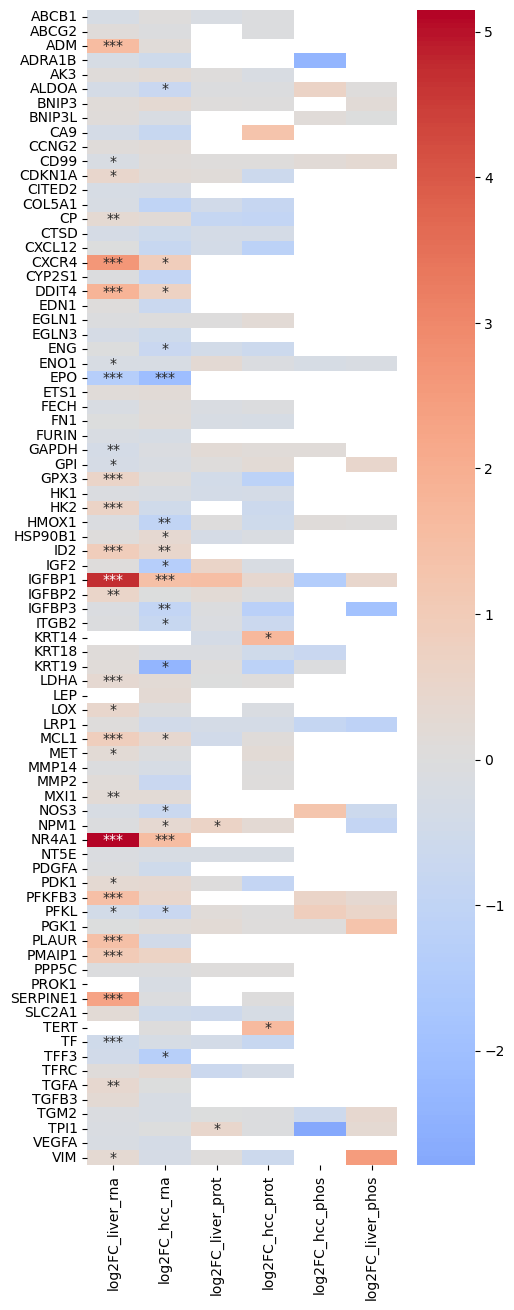

In [111]:
plt.subplots(figsize=(5,15))

hypoxia_heatmap = hypoxia_heatmap.sort_index()

sns.heatmap(hypoxia_heatmap, cmap='coolwarm', yticklabels=True, center=0, annot=sig_annot, fmt='')

plt.savefig('Hypoxia_induced_changes_all_omics.pdf', dpi=300, bbox_inches='tight')